## SVM Classification using Open-Meteo Weather API
Author: Kushagra Bhargava

Registration Number: 23BAI10987

Application Number: IN26011651

Batch Number: 1A

Email ID: kushagra.23bai10987@vitbhopal.ac.in

In [12]:
import requests,pandas as pd,numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report
import seaborn as sns
import matplotlib.pyplot as plt

In [13]:
latitude=28.6139
longitude=77.2090
url=f"https://api.open-meteo.com/v1/forecast?latitude={latitude}&longitude={longitude}&hourly=temperature_2m,relative_humidity_2m,surface_pressure,wind_speed_10m&forecast_days=7"
data=requests.get(url).json()
df=pd.DataFrame({
'Time':data['hourly']['time'],
'Temperature':data['hourly']['temperature_2m'],
'Humidity':data['hourly']['relative_humidity_2m'],
'Pressure':data['hourly']['surface_pressure'],
'WindSpeed':data['hourly']['wind_speed_10m']
})
df.head()

,Time,Temperature,Humidity,Pressure,WindSpeed
0,2026-07-27T00:00,29.7,84,975.1,2.3
1,2026-07-27T01:00,29.9,82,975.2,2.4
2,2026-07-27T02:00,30.5,79,975.7,1.7
3,2026-07-27T03:00,31.4,75,975.7,2.3
4,2026-07-27T04:00,32.4,69,975.6,2.1


In [14]:
df["Weather_Class"]=np.where(df["Temperature"]>=25,"Warm","Cool")
if df["Weather_Class"].nunique()==1:
    print("Only one class found using 25°C threshold. Using median threshold for demonstration.")
    t=df["Temperature"].median()
    df["Weather_Class"]=np.where(df["Temperature"]>=t,"Warm","Cool")
df.head()

Only one class found using 25°C threshold. Using median threshold for demonstration.


,Time,Temperature,Humidity,Pressure,WindSpeed,Weather_Class
0,2026-07-27T00:00,29.7,84,975.1,2.3,Warm
1,2026-07-27T01:00,29.9,82,975.2,2.4,Warm
2,2026-07-27T02:00,30.5,79,975.7,1.7,Warm
3,2026-07-27T03:00,31.4,75,975.7,2.3,Warm
4,2026-07-27T04:00,32.4,69,975.6,2.1,Warm


In [15]:
print("Features:",['Temperature','Humidity','Pressure','WindSpeed'])
print("Target: Weather_Class")
print(df.isnull().sum())

Features: ['Temperature', 'Humidity', 'Pressure', 'WindSpeed']
Target: Weather_Class
Time             0
Temperature      0
Humidity         0
Pressure         0
WindSpeed        0
Weather_Class    0
dtype: int64


In [16]:
df=df.drop(columns=["Time"])
le=LabelEncoder()
df["Weather_Class"]=le.fit_transform(df["Weather_Class"])
X=df.drop("Weather_Class",axis=1)
y=df["Weather_Class"]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [17]:
model=SVC(kernel='rbf',random_state=42)
model.fit(X_train,y_train)
y_pred=model.predict(X_test)

Accuracy: 0.8823529411764706
Precision: 0.9473684210526315
Recall: 0.8571428571428571
F1: 0.9
              precision    recall  f1-score   support

           0       0.80      0.92      0.86        13
           1       0.95      0.86      0.90        21

    accuracy                           0.88        34
   macro avg       0.87      0.89      0.88        34
weighted avg       0.89      0.88      0.88        34



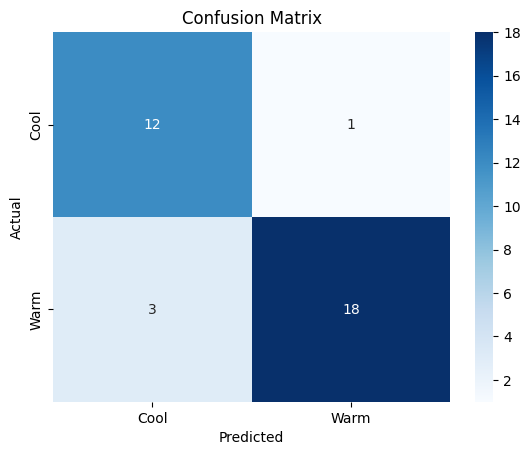

In [18]:
print("Accuracy:",accuracy_score(y_test,y_pred))
print("Precision:",precision_score(y_test,y_pred))
print("Recall:",recall_score(y_test,y_pred))
print("F1:",f1_score(y_test,y_pred))
print(classification_report(y_test,y_pred))
cm=confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=['Cool','Warm'],yticklabels=['Cool','Warm'])
plt.xlabel("Predicted");plt.ylabel("Actual");plt.title("Confusion Matrix");plt.show()

## Observations
1. SVM successfully classifies weather into Warm and Cool.
2. Feature scaling improves SVM performance.
3. Confusion matrix shows the classification quality.

## Conclusion
This assignment used weather data from the Open-Meteo API to build an SVM classifier. Temperature, humidity, pressure and wind speed were used as features. Data preprocessing included handling missing values, label encoding and feature scaling using StandardScaler. The RBF-kernel SVM achieved effective classification performance as measured by accuracy, precision, recall and F1-score. Feature scaling is important because SVM is distance-based and performs better when features are on similar scales. One advantage of SVM is its ability to model complex nonlinear boundaries using kernels. One limitation is that it can require careful parameter tuning and may become slow on very large datasets.